# Wellbeing & Burnout Risk Assessment

## Purpose
Identify employees at risk of burnout and assess organizational wellbeing indicators to enable proactive interventions.

## Key Metrics
- **Burnout Risk Score**: Composite score based on work hours, stress, exhaustion, and wellbeing indicators
- **Work-Life Balance Score**: Self-reported balance and boundary-setting behaviors
- **PTO Usage Rate**: Actual PTO taken vs available (low usage = burnout risk)
- **Average Weekly Hours**: Sustained long hours predict burnout

## Research Foundation
- Maslach Burnout Inventory (Maslach & Jackson, 1981)
- Job Demands-Resources model (Bakker & Demerouti, 2007)
- WHO guidelines on burnout (2019)

In [1]:
import pandas as pdimport numpy as npimport matplotlib.pyplot as pltimport seaborn as snsfrom scipy import statsimport os# Set display optionspd.set_option('display.max_columns', None)pd.set_option('display.width', None)sns.set_style('whitegrid')plt.rcParams['figure.figsize'] = (12, 6)# Load datasetsif not os.path.exists('../data/employees.csv'):    print("Generating sample data...")    exec(open('../data/generate_sample_data.py').read())else:    print("Loading existing data...")employees = pd.read_csv('../data/employees.csv')pulse_surveys = pd.read_csv('../data/pulse_surveys.csv')print(f"\nLoaded {len(employees)} employee records")print(f"Loaded {len(pulse_surveys)} survey responses")

Loading existing data...

Loaded 500 employee records
Loaded 1694 survey responses


## 1. Burnout Risk Overview

Assess overall burnout risk across the organization.

BURNOUT RISK DISTRIBUTION

Overall Statistics:
  Average burnout risk score: 39.6/100
  Median: 38.7
  Std Dev: 14.6

Risk Categories:
    Low Risk       : 268 employees ( 53.6%)
    Moderate Risk  : 185 employees ( 37.0%)
  ⚠ High Risk      :  45 employees (  9.0%)
  ⚠ Critical Risk  :   2 employees (  0.4%)

⚠ URGENT: 47 employees (9.4%) at high/critical burnout risk


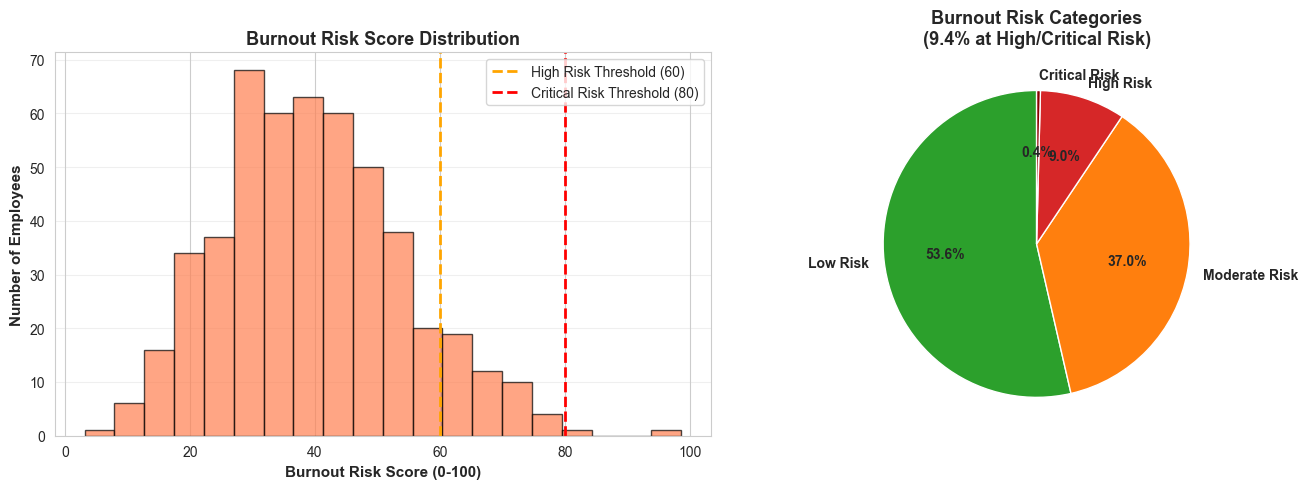

In [2]:
# Categorize burnout riskemployees['burnout_category'] = pd.cut(    employees['burnout_risk_score'],    bins=[0, 40, 60, 80, 100],    labels=['Low Risk', 'Moderate Risk', 'High Risk', 'Critical Risk'])# Calculate risk distributionrisk_counts = employees['burnout_category'].value_counts()risk_pcts = (risk_counts / len(employees) * 100).round(1)print(f"{'='*80}")print(f"BURNOUT RISK DISTRIBUTION")print(f"{'='*80}")print(f"\nOverall Statistics:")print(f"  Average burnout risk score: {employees['burnout_risk_score'].mean():.1f}/100")print(f"  Median: {employees['burnout_risk_score'].median():.1f}")print(f"  Std Dev: {employees['burnout_risk_score'].std():.1f}")print(f"\nRisk Categories:")for category in ['Low Risk', 'Moderate Risk', 'High Risk', 'Critical Risk']:    if category in risk_counts.index:        count = risk_counts[category]        pct = risk_pcts[category]        marker = "⚠" if category in ['High Risk', 'Critical Risk'] else " "        print(f"  {marker} {category:15s}: {count:3d} employees ({pct:5.1f}%)")# Calculate high-risk thresholdhigh_risk_count = risk_counts.get('High Risk', 0) + risk_counts.get('Critical Risk', 0)high_risk_pct = (high_risk_count / len(employees) * 100)print(f"\n⚠ URGENT: {high_risk_count} employees ({high_risk_pct:.1f}%) at high/critical burnout risk")print(f"{'='*80}")# Visualize burnout risk distributionfig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))# Histogram of burnout scoresax1.hist(employees['burnout_risk_score'], bins=20, color='coral', alpha=0.7, edgecolor='black')ax1.axvline(x=60, color='orange', linestyle='--', linewidth=2, label='High Risk Threshold (60)')ax1.axvline(x=80, color='red', linestyle='--', linewidth=2, label='Critical Risk Threshold (80)')ax1.set_xlabel('Burnout Risk Score (0-100)', fontsize=11, fontweight='bold')ax1.set_ylabel('Number of Employees', fontsize=11, fontweight='bold')ax1.set_title('Burnout Risk Score Distribution', fontsize=13, fontweight='bold')ax1.legend()ax1.grid(axis='y', alpha=0.3)# Pie chart of risk categoriescolors_risk = ['#2ca02c', '#ff7f0e', '#d62728', '#8b0000']  # Green, Orange, Red, Dark Redax2.pie(risk_counts.values, labels=risk_counts.index, autopct='%1.1f%%',        colors=colors_risk[:len(risk_counts)], startangle=90,        textprops={'fontsize': 10, 'fontweight': 'bold'})ax2.set_title(f'Burnout Risk Categories\n({high_risk_pct:.1f}% at High/Critical Risk)',               fontsize=13, fontweight='bold')plt.tight_layout()plt.show()

## 2. Burnout Risk by Department

Identify which departments have the highest burnout rates.

BURNOUT RISK BY DEPARTMENT
                  Avg Burnout Score  Std Dev  Count  Avg Weekly Hours  \
department                                                              
Sales                         46.79    15.35     50             48.15   
Finance                       46.07    15.15     59             51.07   
Customer Success              39.97    17.33     68             46.57   
Operations                    39.30    15.44     58             42.43   
Engineering                   38.80    14.47     57             46.87   
Marketing                     38.01    12.15     73             43.36   
Product                       36.14    12.89     69             43.15   
HR                            34.49    10.40     66             40.35   

                  PTO Usage %  Attrition %  
department                                  
Sales                    57.0         12.0  
Finance                  56.0          5.0  
Customer Success         62.0          7.0  
Operations       

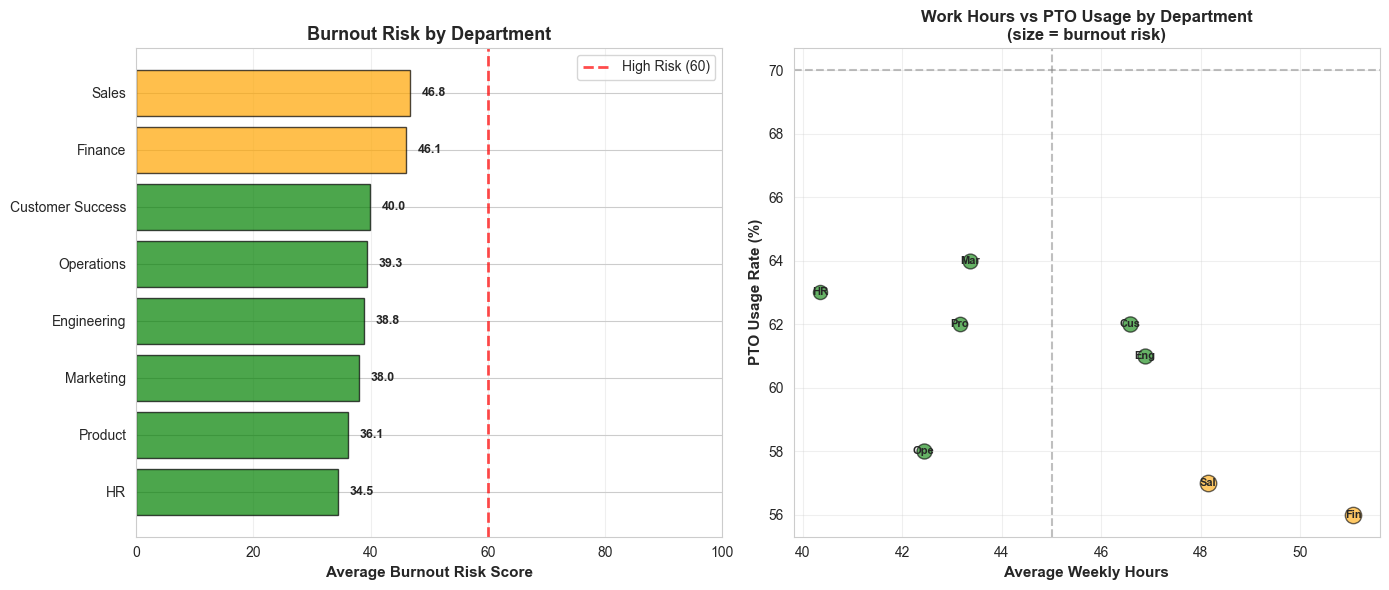


💡 INSIGHT: Departments in top-right quadrant (high hours, low PTO) are at highest risk


In [3]:
# Department-level burnout analysisdept_burnout = employees.groupby('department').agg({    'burnout_risk_score': ['mean', 'std', 'count'],    'avg_weekly_hours': 'mean',    'pto_usage_rate': 'mean',    'has_left': 'mean'}).round(2)dept_burnout.columns = ['Avg Burnout Score', 'Std Dev', 'Count', 'Avg Weekly Hours', 'PTO Usage %', 'Attrition %']dept_burnout = dept_burnout.sort_values('Avg Burnout Score', ascending=False)dept_burnout['PTO Usage %'] = (dept_burnout['PTO Usage %'] * 100).round(1)dept_burnout['Attrition %'] = (dept_burnout['Attrition %'] * 100).round(1)print(f"{'='*80}")print(f"BURNOUT RISK BY DEPARTMENT")print(f"{'='*80}")print(dept_burnout)# Identify high-risk departmentshigh_risk_depts = dept_burnout[dept_burnout['Avg Burnout Score'] > 60]if len(high_risk_depts) > 0:    print(f"\n⚠ HIGH-RISK DEPARTMENTS (Avg Burnout Score > 60):")    for dept in high_risk_depts.index:        score = high_risk_depts.loc[dept, 'Avg Burnout Score']        hours = high_risk_depts.loc[dept, 'Avg Weekly Hours']        pto = high_risk_depts.loc[dept, 'PTO Usage %']        print(f"  • {dept}:")        print(f"      Burnout Score: {score:.1f}")        print(f"      Avg Hours: {hours:.1f}/week")        print(f"      PTO Usage: {pto:.1f}%")print(f"\n{'='*80}")# Visualize department comparisonfig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))# Burnout score by departmentdept_sorted = dept_burnout.sort_values('Avg Burnout Score')colors = ['red' if x > 60 else 'orange' if x > 40 else 'green' for x in dept_sorted['Avg Burnout Score']]bars = ax1.barh(dept_sorted.index, dept_sorted['Avg Burnout Score'], color=colors, alpha=0.7, edgecolor='black')ax1.axvline(x=60, color='red', linestyle='--', linewidth=2, alpha=0.7, label='High Risk (60)')ax1.set_xlabel('Average Burnout Risk Score', fontsize=11, fontweight='bold')ax1.set_title('Burnout Risk by Department', fontsize=13, fontweight='bold')ax1.set_xlim(0, 100)ax1.legend()ax1.grid(axis='x', alpha=0.3)# Add value labelsfor i, (idx, row) in enumerate(dept_sorted.iterrows()):    ax1.text(row['Avg Burnout Score'] + 2, i, f"{row['Avg Burnout Score']:.1f}",             va='center', fontsize=9, fontweight='bold')# Hours vs PTO usage scatterfor dept in dept_burnout.index:    hours = dept_burnout.loc[dept, 'Avg Weekly Hours']    pto = dept_burnout.loc[dept, 'PTO Usage %']    score = dept_burnout.loc[dept, 'Avg Burnout Score']        # Color by burnout score    color = 'red' if score > 60 else 'orange' if score > 40 else 'green'        ax2.scatter(hours, pto, s=score*3, color=color, alpha=0.6, edgecolors='black', linewidth=1)    ax2.text(hours, pto, dept[:3], fontsize=8, ha='center', va='center', fontweight='bold')ax2.set_xlabel('Average Weekly Hours', fontsize=11, fontweight='bold')ax2.set_ylabel('PTO Usage Rate (%)', fontsize=11, fontweight='bold')ax2.set_title('Work Hours vs PTO Usage by Department\n(size = burnout risk)', fontsize=12, fontweight='bold')ax2.grid(alpha=0.3)# Add quadrant labelsax2.axhline(y=70, color='gray', linestyle='--', alpha=0.5)ax2.axvline(x=45, color='gray', linestyle='--', alpha=0.5)plt.tight_layout()plt.show()print(f"\n💡 INSIGHT: Departments in top-right quadrant (high hours, low PTO) are at highest risk")print(f"{'='*80}")

## 3. Burnout Risk Factors

Analyze which factors most strongly predict burnout risk.

BURNOUT RISK FACTORS - Correlation Analysis
  Performance Rating       : r=-0.541 ✓ (decreases burnout)
  Weekly Work Hours        : r= 0.421 ✓ (increases burnout)
  Manager Effectiveness    : r=-0.372 ✓ (decreases burnout)
  PTO Usage Rate           : r=-0.252 ✓ (decreases burnout)
  Tenure (months)          : r=-0.078  (decreases burnout)



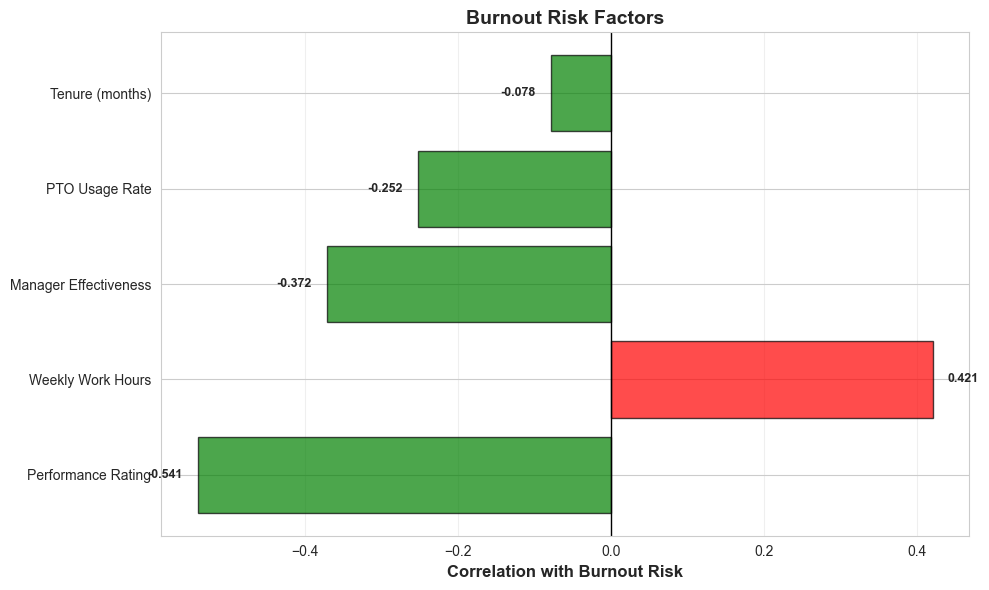

In [4]:
# Correlation analysisfactors = {    'avg_weekly_hours': 'Weekly Work Hours',    'pto_usage_rate': 'PTO Usage Rate',    'manager_effectiveness_score': 'Manager Effectiveness',    'tenure_months': 'Tenure (months)',    'performance_rating': 'Performance Rating'}correlations = {}for col, label in factors.items():    corr, pval = stats.pearsonr(employees[col], employees['burnout_risk_score'])    correlations[label] = {'correlation': corr, 'p_value': pval}corr_df = pd.DataFrame(correlations).Tcorr_df = corr_df.sort_values('correlation', key=abs, ascending=False)corr_df['significant'] = corr_df['p_value'] < 0.05print(f"{'='*80}")print(f"BURNOUT RISK FACTORS - Correlation Analysis")print(f"{'='*80}")for factor, row in corr_df.iterrows():    sig = "✓" if row['significant'] else ""    direction = "increases" if row['correlation'] > 0 else "decreases"    print(f"  {factor:25s}: r={row['correlation']:6.3f} {sig} ({direction} burnout)")print(f"\n{'='*80}")# Visualize correlationsfig, ax = plt.subplots(figsize=(10, 6))y_pos = np.arange(len(corr_df))colors = ['red' if corr > 0 else 'green' for corr in corr_df['correlation']]bars = ax.barh(y_pos, corr_df['correlation'], color=colors, alpha=0.7, edgecolor='black')ax.set_yticks(y_pos)ax.set_yticklabels(corr_df.index, fontsize=10)ax.set_xlabel('Correlation with Burnout Risk', fontsize=12, fontweight='bold')ax.set_title('Burnout Risk Factors', fontsize=14, fontweight='bold')ax.axvline(x=0, color='black', linewidth=1)ax.grid(axis='x', alpha=0.3)# Add value labelsfor i, (idx, row) in enumerate(corr_df.iterrows()):    x_pos = row['correlation'] + (0.02 if row['correlation'] > 0 else -0.02)    ha = 'left' if row['correlation'] > 0 else 'right'    ax.text(x_pos, i, f"{row['correlation']:.3f}",             va='center', ha=ha, fontsize=9, fontweight='bold')plt.tight_layout()plt.show()

## 4. Burnout Impact on Performance & Retention

Quantify the business impact of burnout through performance and attrition.

BURNOUT IMPACT ON PERFORMANCE & RETENTION
                  Avg Performance  Attrition Rate  Total Count
burnout_category                                              
Low Risk                    3.914             6.0          268
Moderate Risk               3.586             4.3          185
High Risk                   3.264            24.4           45
Critical Risk               2.980            50.0            2

📊 BUSINESS IMPACT:
  Performance gap (Low vs High risk): 0.65 points
  Attrition gap (High vs Low risk): 18.4 percentage points

⚠ High-burnout employees are 3.1x more likely to leave



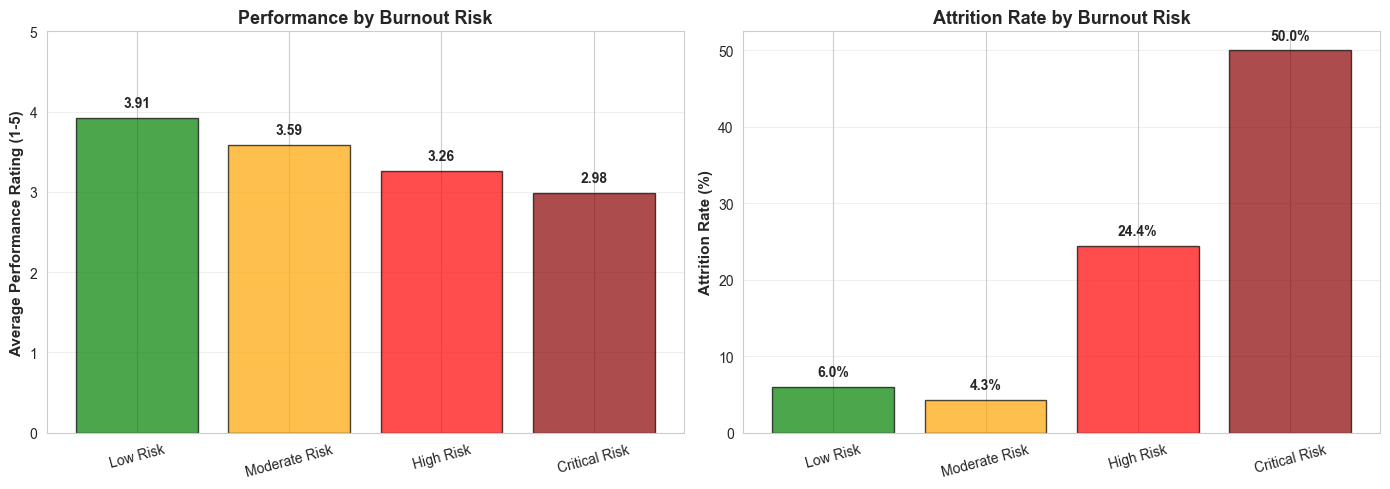

In [5]:
# Performance by burnout categoryburnout_impact = employees.groupby('burnout_category').agg({    'performance_rating': ['mean', 'std'],    'has_left': ['sum', 'mean', 'count']}).round(3)burnout_impact.columns = ['Avg Performance', 'Std Dev', 'Left Count', 'Attrition Rate', 'Total Count']burnout_impact['Attrition Rate'] = (burnout_impact['Attrition Rate'] * 100).round(1)print(f"{'='*80}")print(f"BURNOUT IMPACT ON PERFORMANCE & RETENTION")print(f"{'='*80}")print(burnout_impact[['Avg Performance', 'Attrition Rate', 'Total Count']])# Calculate impact magnitudelow_risk_perf = burnout_impact.loc['Low Risk', 'Avg Performance']high_risk_perf = burnout_impact.loc['High Risk', 'Avg Performance'] if 'High Risk' in burnout_impact.index else 0performance_gap = low_risk_perf - high_risk_perflow_risk_attrition = burnout_impact.loc['Low Risk', 'Attrition Rate']high_risk_attrition = burnout_impact.loc['High Risk', 'Attrition Rate'] if 'High Risk' in burnout_impact.index else 0attrition_gap = high_risk_attrition - low_risk_attritionprint(f"\n📊 BUSINESS IMPACT:")print(f"  Performance gap (Low vs High risk): {performance_gap:.2f} points")print(f"  Attrition gap (High vs Low risk): {attrition_gap:.1f} percentage points")print(f"\n⚠ High-burnout employees are {attrition_gap/low_risk_attrition:.1f}x more likely to leave")print(f"\n{'='*80}")# Visualize burnout impactfig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))# Performance by burnout categorycategories = ['Low Risk', 'Moderate Risk', 'High Risk', 'Critical Risk']perf_values = [burnout_impact.loc[cat, 'Avg Performance'] if cat in burnout_impact.index else 0                for cat in categories]colors_cat = ['green', 'orange', 'red', 'darkred']bars1 = ax1.bar(categories, perf_values, color=colors_cat, alpha=0.7, edgecolor='black')ax1.set_ylabel('Average Performance Rating (1-5)', fontsize=11, fontweight='bold')ax1.set_title('Performance by Burnout Risk', fontsize=13, fontweight='bold')ax1.set_ylim(0, 5)ax1.tick_params(axis='x', rotation=15)ax1.grid(axis='y', alpha=0.3)# Add value labelsfor bar, val in zip(bars1, perf_values):    if val > 0:        ax1.text(bar.get_x() + bar.get_width()/2., val + 0.1,                f'{val:.2f}', ha='center', va='bottom', fontsize=10, fontweight='bold')# Attrition rate by burnout categoryattrition_values = [burnout_impact.loc[cat, 'Attrition Rate'] if cat in burnout_impact.index else 0                     for cat in categories]bars2 = ax2.bar(categories, attrition_values, color=colors_cat, alpha=0.7, edgecolor='black')ax2.set_ylabel('Attrition Rate (%)', fontsize=11, fontweight='bold')ax2.set_title('Attrition Rate by Burnout Risk', fontsize=13, fontweight='bold')ax2.tick_params(axis='x', rotation=15)ax2.grid(axis='y', alpha=0.3)# Add value labelsfor bar, val in zip(bars2, attrition_values):    if val > 0:        ax2.text(bar.get_x() + bar.get_width()/2., val + 1,                f'{val:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')plt.tight_layout()plt.show()

## 5. High-Risk Employee Identification

Generate actionable list of employees requiring immediate intervention.

In [6]:
# Identify high-risk employeeshigh_risk_employees = employees[employees['burnout_risk_score'] > 70].copy()high_risk_employees = high_risk_employees.sort_values('burnout_risk_score', ascending=False)print(f"{'='*80}")print(f"HIGH-RISK EMPLOYEES REQUIRING INTERVENTION")print(f"{'='*80}")print(f"\nTotal high-risk employees: {len(high_risk_employees)}")# Summary by departmenthigh_risk_by_dept = high_risk_employees['department'].value_counts()print(f"\nBreakdown by Department:")for dept, count in high_risk_by_dept.items():    print(f"  {dept:20s}: {count} employees")# Show top 10 highest riskprint(f"\n{'='*80}")print(f"TOP 10 HIGHEST BURNOUT RISK (for immediate manager intervention)")print(f"{'='*80}")top_risk = high_risk_employees.head(10)[[    'employee_id', 'department', 'level', 'burnout_risk_score',     'avg_weekly_hours', 'pto_usage_rate', 'manager_effectiveness_score']].copy()top_risk['pto_usage_rate'] = (top_risk['pto_usage_rate'] * 100).round(1)top_risk.columns = ['Employee ID', 'Department', 'Level', 'Burnout Score',                     'Weekly Hours', 'PTO Usage %', 'Manager Score']print(top_risk.to_string(index=False))print(f"\n{'='*80}")# Intervention recommendationsprint(f"\n💡 RECOMMENDED INTERVENTIONS FOR HIGH-RISK EMPLOYEES:")print(f"{'='*80}")print(f"\n1. IMMEDIATE (Critical Risk >80):")critical_count = len(employees[employees['burnout_risk_score'] > 80])print(f"   • {critical_count} employees require urgent manager intervention")print(f"   • Schedule 1:1 within 48 hours to discuss workload and wellbeing")print(f"   • Consider temporary workload reduction or PTO requirement")print(f"   • Connect with EAP (Employee Assistance Program) resources")print(f"\n2. SHORT-TERM (High Risk 60-80):")high_count = len(employees[(employees['burnout_risk_score'] >= 60) & (employees['burnout_risk_score'] <= 80)])print(f"   • {high_count} employees need proactive support")print(f"   • Review and adjust workload distribution")print(f"   • Encourage PTO usage (current average: {employees['pto_usage_rate'].mean()*100:.1f}%)")print(f"   • Implement no-meeting blocks for focused work")print(f"\n3. SYSTEMIC (Department-level):")if len(high_risk_depts) > 0:    for dept in high_risk_depts.index:        print(f"   • {dept}: Review team capacity and hiring needs")else:    print(f"   • No departments currently at systemic risk")print(f"\n4. PREVENTIVE (Organization-wide):")print(f"   • Enforce maximum work hours policy (recommended: 45 hours/week)")print(f"   • Track and report PTO usage quarterly")print(f"   • Train managers on burnout recognition and intervention")print(f"   • Implement flexible work arrangements where possible")print(f"\n{'='*80}")

HIGH-RISK EMPLOYEES REQUIRING INTERVENTION

Total high-risk employees: 15

Breakdown by Department:
  Finance             : 5 employees
  Sales               : 4 employees
  Operations          : 3 employees
  Customer Success    : 1 employees
  Engineering         : 1 employees
  Marketing           : 1 employees

TOP 10 HIGHEST BURNOUT RISK (for immediate manager intervention)
 Employee ID       Department          Level  Burnout Score  Weekly Hours  PTO Usage %  Manager Score
        1123 Customer Success            IC1           98.6          58.8         49.1          0.349
        1028            Sales            IC4           83.2          54.8         51.0          0.220
        1052       Operations       Director           77.0          51.4         62.3          0.691
        1450            Sales        Manager           76.9          56.5         74.3          0.430
        1056      Engineering            IC4           76.8          52.2         19.8          0.389
      

## 6. Wellbeing Index from Pulse Surveys

Analyze wellbeing survey responses to validate burnout risk scores.

WELLBEING SURVEY RESULTS - Q4 2024

Overall Wellbeing Index: 3.43/5.0

Wellbeing Dimensions (1-5 scale):
    Stress Manageable        : 3.37
    Feeling Energized        : 3.42
    Adequate Rest            : 3.42
    Manageable Workload      : 3.45
    Boundary Respect         : 3.45
    Work-Life Balance        : 3.46

⚠ AREAS OF CONCERN (Score < 3.5):
   • Stress Manageable: 3.37
   • Feeling Energized: 3.42
   • Adequate Rest: 3.42
   • Manageable Workload: 3.45
   • Boundary Respect: 3.45
   • Work-Life Balance: 3.46



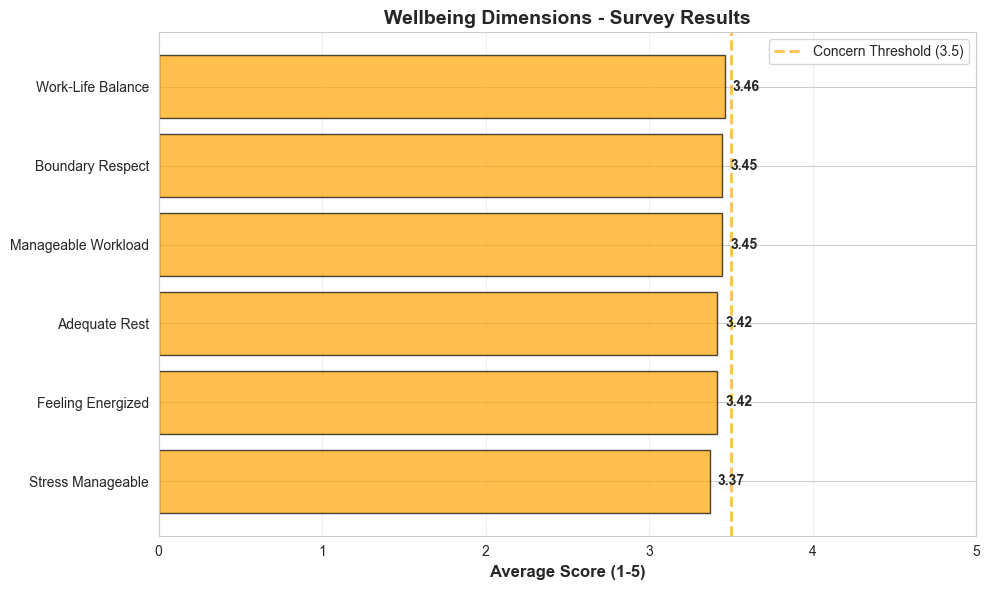

In [7]:
# Latest survey wellbeing analysislatest_survey = pulse_surveys[pulse_surveys['survey_id'] == 'Q4_2025'].copy()# Wellbeing dimensionswellbeing_dims = [    'work_life_balance',    'manageable_workload',    'adequate_rest',    'feeling_energized',    'stress_level_manageable',    'boundary_respect']# Calculate average scoreswellbeing_scores = {}for dim in wellbeing_dims:    wellbeing_scores[dim] = latest_survey[dim].mean()wellbeing_df = pd.DataFrame(wellbeing_scores.items(), columns=['Dimension', 'Avg Score'])wellbeing_df = wellbeing_df.sort_values('Avg Score', ascending=True)# Readable namesreadable_wellbeing = {    'work_life_balance': 'Work-Life Balance',    'manageable_workload': 'Manageable Workload',    'adequate_rest': 'Adequate Rest',    'feeling_energized': 'Feeling Energized',    'stress_level_manageable': 'Stress Manageable',    'boundary_respect': 'Boundary Respect'}wellbeing_df['Dimension'] = wellbeing_df['Dimension'].map(readable_wellbeing)print(f"{'='*80}")print(f"WELLBEING SURVEY RESULTS - Q4 2024")print(f"{'='*80}")print(f"\nOverall Wellbeing Index: {latest_survey['wellbeing_index'].mean():.2f}/5.0")print(f"\nWellbeing Dimensions (1-5 scale):")for _, row in wellbeing_df.iterrows():    status = "⚠" if row['Avg Score'] < 3.0 else " "    print(f"  {status} {row['Dimension']:25s}: {row['Avg Score']:.2f}")# Identify lowest-scoring dimensionslow_wellbeing = wellbeing_df[wellbeing_df['Avg Score'] < 3.5]if len(low_wellbeing) > 0:    print(f"\n⚠ AREAS OF CONCERN (Score < 3.5):")    for _, row in low_wellbeing.iterrows():        print(f"   • {row['Dimension']}: {row['Avg Score']:.2f}")print(f"\n{'='*80}")# Visualize wellbeing dimensionsfig, ax = plt.subplots(figsize=(10, 6))colors = ['red' if score < 3.0 else 'orange' if score < 3.5 else 'green'           for score in wellbeing_df['Avg Score']]bars = ax.barh(wellbeing_df['Dimension'], wellbeing_df['Avg Score'],                color=colors, alpha=0.7, edgecolor='black')ax.axvline(x=3.5, color='orange', linestyle='--', linewidth=2, alpha=0.7, label='Concern Threshold (3.5)')ax.set_xlabel('Average Score (1-5)', fontsize=12, fontweight='bold')ax.set_title('Wellbeing Dimensions - Survey Results', fontsize=14, fontweight='bold')ax.set_xlim(0, 5)ax.legend()ax.grid(axis='x', alpha=0.3)# Add value labelsfor i, (idx, row) in enumerate(wellbeing_df.iterrows()):    ax.text(row['Avg Score'] + 0.05, i, f"{row['Avg Score']:.2f}",             va='center', fontsize=10, fontweight='bold')plt.tight_layout()plt.show()

## Key Takeaways

1. **Burnout is measurable and actionable**: Use composite scoring to identify at-risk employees before attrition occurs
2. **Work hours and PTO usage are leading indicators**: Monitor these metrics as early warning signals
3. **Manager quality protects against burnout**: Good managers buffer workplace stress
4. **Burnout drives attrition and reduces performance**: High-risk employees are significantly more likely to leave and underperform

**Recommended Next Steps**:
- Implement immediate interventions for critical-risk employees (score >80)
- Address systemic issues in high-risk departments
- Enforce work hour limits and PTO minimum usage policies
- Train managers on burnout recognition and prevention
- Track wellbeing metrics quarterly to measure improvement